# Facial Emotion Recognition: Traditional CNN vs Dilated CNN
### Dataset 1 (Train): FER2013 | Dataset 2 (Test/Validation): RAF-DB
**Framework:** PyTorch | **Runtime:** T4 GPU

## ⚙️ Step 1 — Setup & Install

In [1]:
# Install required libraries and connect to Kaggle to download datasets
!pip install -q kaggle torchmetrics codecarbon thop opencv-python

In [2]:
import json, os

creds = {"username": "omarwaleedz", "key": "KGAT_4f1460e53f8976aa822a7836edd22069"}

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(creds, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('kaggle.json created!')

kaggle.json created!


In [3]:
# Set up Kaggle credentials and download both datasets
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# FER2013 — training dataset
!kaggle datasets download -d msambare/fer2013 -p /content/fer2013 --unzip

# RAF-DB — validation/test dataset (cross-dataset evaluation)
!kaggle datasets download -d shuvoalok/raf-db-dataset -p /content/rafdb --unzip

cp: cannot stat 'kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/msambare/fer2013
License(s): DbCL-1.0
100% 60.3M/60.3M [00:04<00:00, 14.0MB/s]

Dataset URL: https://www.kaggle.com/datasets/shuvoalok/raf-db-dataset
License(s): other
100% 37.7M/37.7M [00:03<00:00, 10.7MB/s]



## 📦 Step 2 — Imports & Config

In [4]:
# Import all libraries and define global config (seed, paths, hyperparameters)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from torchmetrics import Accuracy, F1Score, CohenKappa, MatthewsCorrCoef, AUROC, Recall, Precision
from thop import profile
from codecarbon import EmissionsTracker
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import random, time

# --- Global Config ---
SEED       = 42
IMG_SIZE   = 48
BATCH_SIZE = 128
EPOCHS     = 50
LR         = 1e-3
NUM_CLASSES = 7
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Shared emotion classes (FER2013 & RAF-DB both have these 7)
CLASSES = ['Angry','Disgust','Fear','Happy','Neutral','Sad','Surprise']

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f'Device: {DEVICE}')
print(f'Classes: {CLASSES}')

Device: cuda
Classes: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


## 🔧 Step 3 — Preprocessing & Data Loaders

In [5]:
from PIL import Image

def preprocess_image(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)
    img = Image.fromarray(img).convert('L')
    return img

In [6]:
# Define preprocessing pipelines — augmentation for training, normalization only for eval

# FER2013 images are already 48x48 grayscale; we convert to 3-ch to match pretrained conv expectations
# Augmentation for training, clean normalization only for eval

train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),

    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

eval_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])
print('Transforms defined.')

Transforms defined.


In [7]:
# Load datasets and fix imbalance without oversampling to 50k
fer_train_ds = datasets.ImageFolder('/content/fer2013/train',       loader=preprocess_image, transform=train_transforms)
raf_val_ds   = datasets.ImageFolder('/content/rafdb/DATASET/train', loader=preprocess_image, transform=eval_transforms)
raf_test_ds  = datasets.ImageFolder('/content/rafdb/DATASET/test',  loader=preprocess_image, transform=eval_transforms)

class_counts = np.bincount(fer_train_ds.targets)
sample_weights = [1.0 / class_counts[t] for t in fer_train_ds.targets]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(fer_train_ds),   # IMPORTANT: no /2
    replacement=True
)


print(f'Train: {len(fer_train_ds) // 2} | Val: {len(raf_val_ds)} | Test: {len(raf_test_ds)}')

Train: 14354 | Val: 12271 | Test: 3068


In [8]:
RAF_TO_FER = {
    0: 6,   # Surprise (RAF 1) → index 6 in FER
    1: 2,   # Fear     (RAF 2) → index 2 in FER
    2: 1,   # Disgust  (RAF 3) → index 1 in FER
    3: 3,   # Happy    (RAF 4) → index 3 in FER
    4: 5,   # Sad      (RAF 5) → index 5 in FER
    5: 0,   # Angry    (RAF 6) → index 0 in FER
    6: 4,   # Neutral  (RAF 7) → index 4 in FER
}

# Apply remapping to val and test targets
raf_val_ds.targets  = [RAF_TO_FER[t] for t in raf_val_ds.targets]
raf_test_ds.targets = [RAF_TO_FER[t] for t in raf_test_ds.targets]

# Align class names too
raf_val_ds.classes  = CLASSES
raf_test_ds.classes = CLASSES

print('FER2013 classes:', fer_train_ds.classes)
print('RAF-DB  classes after remap:', raf_val_ds.classes)

FER2013 classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
RAF-DB  classes after remap: ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']


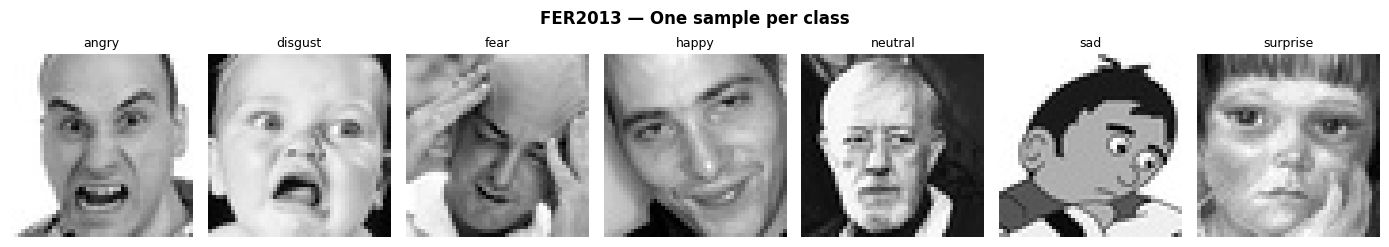

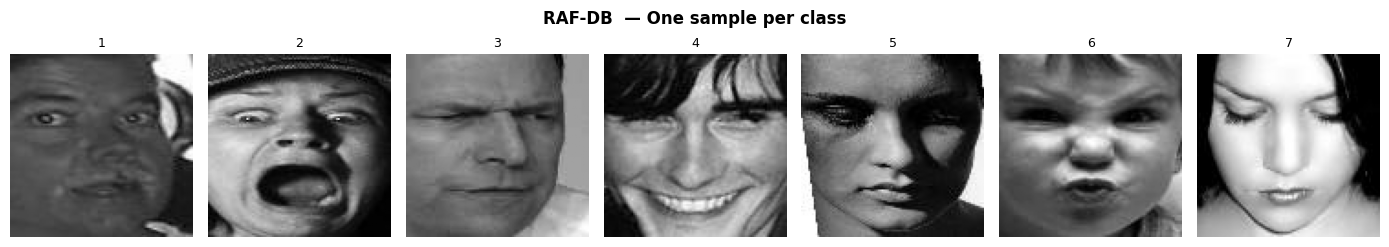

In [9]:
import cv2

def show_samples(root, title):
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 2.5))
    fig.suptitle(title, fontweight='bold')
    classes = sorted(os.listdir(root))[:NUM_CLASSES]
    for ax, cls in zip(axes, classes):
        img_file = os.listdir(os.path.join(root, cls))[0]
        img_path = os.path.join(root, cls, img_file)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        ax.imshow(img, cmap='gray')
        ax.set_title(cls, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples('/content/fer2013/train',        'FER2013 — One sample per class')
show_samples('/content/rafdb/DATASET/train',  'RAF-DB  — One sample per class')

In [10]:
def check_size(root):
    cls = os.listdir(root)[0]
    img_file = os.listdir(os.path.join(root, cls))[0]
    img = cv2.imread(os.path.join(root, cls, img_file))
    print(f'{root} → image size: {img.shape}')

check_size('/content/fer2013/train')
check_size('/content/rafdb/DATASET/train')

/content/fer2013/train → image size: (48, 48, 3)
/content/rafdb/DATASET/train → image size: (100, 100, 3)


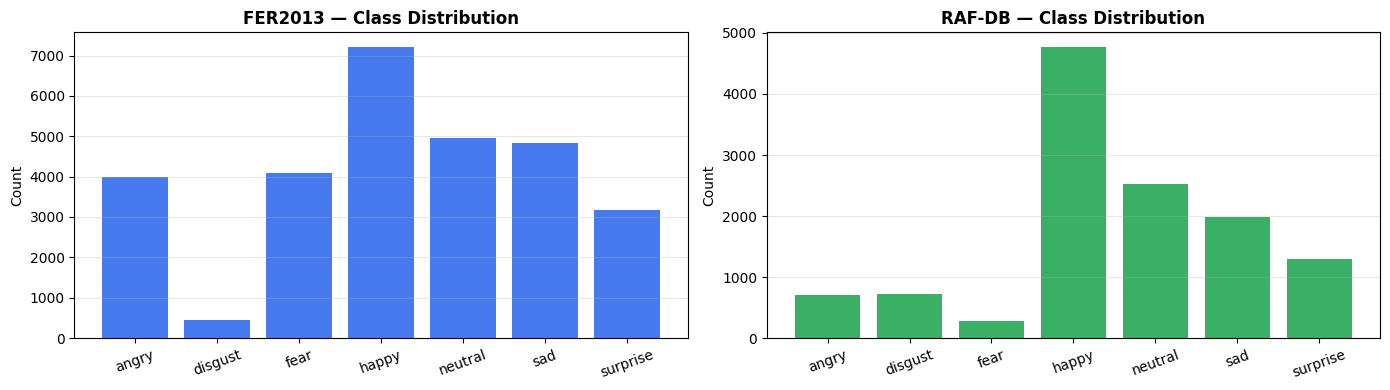

In [11]:
# Compare how balanced each dataset is across the 7 emotion classes
import numpy as np

fer_counts = np.bincount(fer_train_ds.targets)
raf_counts = np.bincount(raf_val_ds.targets)
classes    = fer_train_ds.classes
x          = np.arange(len(classes))
width      = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(x, fer_counts, color='#2563eb', alpha=0.85)
axes[0].set_title('FER2013 — Class Distribution', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(classes, rotation=20)
axes[0].set_ylabel('Count'); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, raf_counts, color='#16a34a', alpha=0.85)
axes[1].set_title('RAF-DB — Class Distribution', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(classes, rotation=20)
axes[1].set_ylabel('Count'); axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

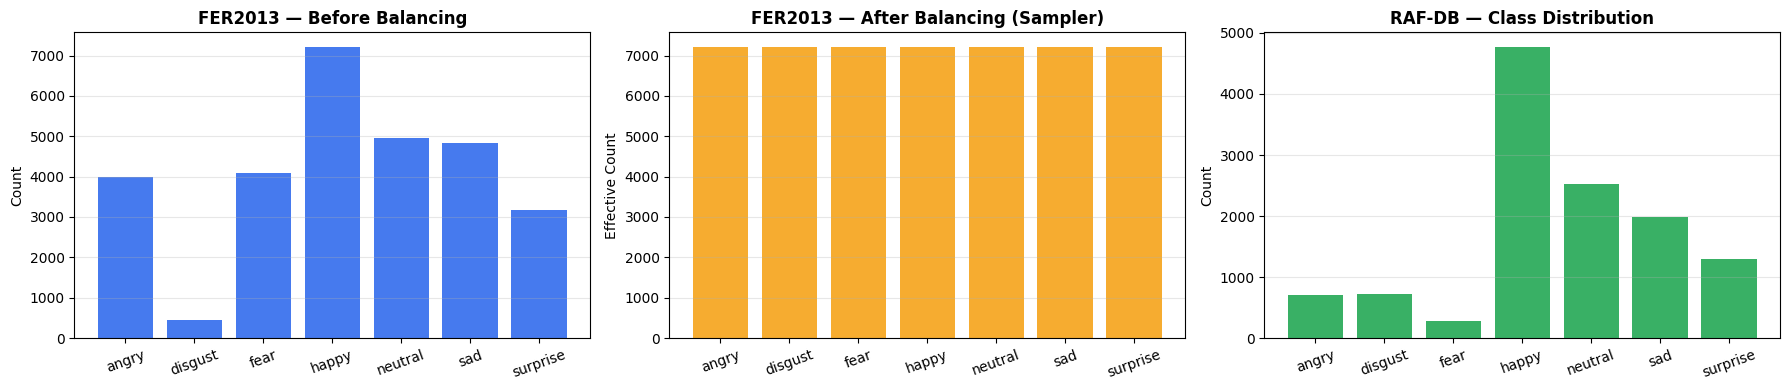

In [12]:
# Compare class distribution before and after balancing, plus RAF-DB distribution
fer_counts    = np.bincount(fer_train_ds.targets)
balanced      = np.ones(len(fer_counts)) * fer_counts.max()   # sampler makes all classes equal
raf_counts    = np.bincount(raf_val_ds.targets)
classes       = fer_train_ds.classes
x             = np.arange(len(classes))
width         = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].bar(x, fer_counts, color='#2563eb', alpha=0.85)
axes[0].set_title('FER2013 — Before Balancing', fontweight='bold')
axes[0].set_xticks(x); axes[0].set_xticklabels(classes, rotation=20)
axes[0].set_ylabel('Count'); axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(x, balanced, color='#f59e0b', alpha=0.85)
axes[1].set_title('FER2013 — After Balancing (Sampler)', fontweight='bold')
axes[1].set_xticks(x); axes[1].set_xticklabels(classes, rotation=20)
axes[1].set_ylabel('Effective Count'); axes[1].grid(axis='y', alpha=0.3)

axes[2].bar(x, raf_counts, color='#16a34a', alpha=0.85)
axes[2].set_title('RAF-DB — Class Distribution', fontweight='bold')
axes[2].set_xticks(x); axes[2].set_xticklabels(classes, rotation=20)
axes[2].set_ylabel('Count'); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
train_loader = DataLoader(fer_train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(raf_val_ds,   batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(raf_test_ds,  batch_size=BATCH_SIZE, shuffle=False,   num_workers=2, pin_memory=True, persistent_workers=True)

print(f'FER2013  → Train : {len(fer_train_ds)} images')
print(f'RAF-DB   → Val   : {len(raf_val_ds)} images')
print(f'RAF-DB   → Test  : {len(raf_test_ds)}  images')
print(f'Class counts (FER2013 train): {dict(zip(fer_train_ds.classes, class_counts))}')

FER2013  → Train : 28709 images
RAF-DB   → Val   : 12271 images
RAF-DB   → Test  : 3068  images
Class counts (FER2013 train): {'angry': np.int64(3995), 'disgust': np.int64(436), 'fear': np.int64(4097), 'happy': np.int64(7215), 'neutral': np.int64(4965), 'sad': np.int64(4830), 'surprise': np.int64(3171)}


In [14]:
# Check image size after preprocessing and transforms are applied
img, label = fer_train_ds[0]
print(f'FER2013 tensor shape: {img.shape}')

img, label = raf_val_ds[0]
print(f'RAF-DB  tensor shape: {img.shape}')

FER2013 tensor shape: torch.Size([1, 48, 48])
RAF-DB  tensor shape: torch.Size([1, 48, 48])


## 🧱 Step 4 — Model Definitions

In [15]:
# Deeper Traditional CNN with more filters and an extra block for better feature extraction
import torch.nn as nn

class TraditionalCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512), nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

print('TraditionalCNN defined.')

TraditionalCNN defined.


In [16]:
# Dilated CNN (optimized for FER)
class DilatedCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1, dilation=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=2, dilation=2),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=2, dilation=2),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=2, dilation=2),
            nn.BatchNorm2d(512), nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

print('DilatedCNN defined.')

DilatedCNN defined.


## 🏋️ Step 5 — Training Loop

In [17]:
# Generic train/eval functions reused for both models

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    criterion = nn.CrossEntropyLoss(label_smoothing=0.2)
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


print('Train/eval functions ready.')

Train/eval functions ready.


In [18]:
# Train both models and track learning curves + training time + carbon emissions

def run_training(model_class, name):
    print(f'\n========== Training {name} ==========')
    model     = model_class().to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.2)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0

    tracker = EmissionsTracker(project_name=name, log_level='error')
    tracker.start()
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer)
        vl, va = evaluate(model, val_loader)
        scheduler.step()

        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_acc'].append(ta)
        history['val_acc'].append(va)

        if va > best_val_acc:
            best_val_acc = va
            torch.save(model.state_dict(), f'/content/{name}_best.h5')

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:03d}/{EPOCHS} | '
                  f'Train Loss: {tl:.4f} Acc: {ta:.4f} | '
                  f'Val Loss: {vl:.4f} Acc: {va:.4f}')

    emissions = tracker.stop()
    train_time = time.time() - t0

    # Load best weights back
    model.load_state_dict(torch.load(f'/content/{name}_best.h5'))

    print(f'\nDone. Best Val Acc: {best_val_acc:.4f}')
    print(f'Training Time : {train_time/60:.2f} min')
    print(f'CO2 Emissions : {emissions*1000:.4f} g CO2eq')

    return model, history, train_time, emissions


# Train Traditional CNN
trad_model, trad_history, trad_time, trad_co2 = run_training(TraditionalCNN, 'TraditionalCNN')

# Train Dilated CNN
dila_model, dila_history, dila_time, dila_co2 = run_training(DilatedCNN, 'DilatedCNN')


========== Training TraditionalCNN ==========


[codecarbon WARNING @ 13:28:59] Multiple instances of codecarbon are allowed to run at the same time.


Epoch 001/50 | Train Loss: 1.8756 Acc: 0.2462 | Val Loss: 2.0966 Acc: 0.1706
Epoch 005/50 | Train Loss: 1.6266 Acc: 0.4599 | Val Loss: 2.1258 Acc: 0.4165
Epoch 010/50 | Train Loss: 1.5107 Acc: 0.5472 | Val Loss: 1.9319 Acc: 0.3961
Epoch 015/50 | Train Loss: 1.4586 Acc: 0.5873 | Val Loss: 1.9730 Acc: 0.3400
Epoch 020/50 | Train Loss: 1.4186 Acc: 0.6108 | Val Loss: 2.0583 Acc: 0.3614
Epoch 025/50 | Train Loss: 1.3790 Acc: 0.6372 | Val Loss: 2.0037 Acc: 0.3683
Epoch 030/50 | Train Loss: 1.3526 Acc: 0.6548 | Val Loss: 1.9843 Acc: 0.3648
Epoch 035/50 | Train Loss: 1.3235 Acc: 0.6755 | Val Loss: 1.9233 Acc: 0.3764
Epoch 040/50 | Train Loss: 1.2973 Acc: 0.6898 | Val Loss: 1.9856 Acc: 0.3503
Epoch 045/50 | Train Loss: 1.2706 Acc: 0.7102 | Val Loss: 1.9883 Acc: 0.3591
Epoch 050/50 | Train Loss: 1.2660 Acc: 0.7123 | Val Loss: 1.9775 Acc: 0.3650

Done. Best Val Acc: 0.4165
Training Time : 17.89 min
CO2 Emissions : 14.3133 g CO2eq

========== Training DilatedCNN ==========
Epoch 001/50 | Train Los

## 📊 Step 6 — Learning Curves

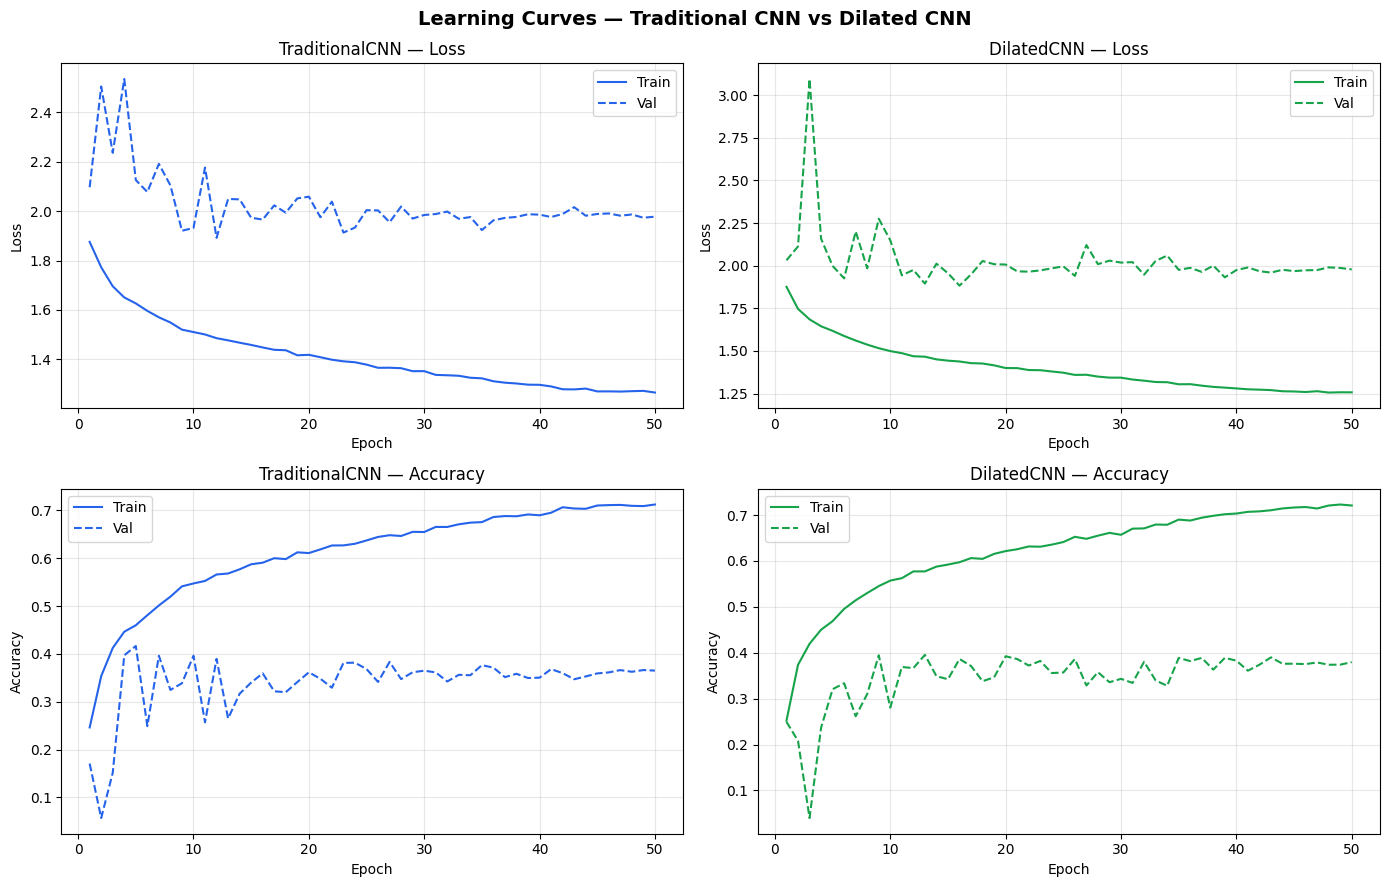

In [19]:
# Plot training vs validation loss and accuracy curves for both models side by side

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Learning Curves — Traditional CNN vs Dilated CNN', fontsize=14, fontweight='bold')
epochs_range = range(1, EPOCHS + 1)

models_info = [
    ('TraditionalCNN', trad_history, '#2563eb'),
    ('DilatedCNN',     dila_history, '#16a34a'),
]

for col, (name, hist, color) in enumerate(models_info):
    # Loss
    axes[0][col].plot(epochs_range, hist['train_loss'], label='Train', color=color)
    axes[0][col].plot(epochs_range, hist['val_loss'],   label='Val',   color=color, linestyle='--')
    axes[0][col].set_title(f'{name} — Loss')
    axes[0][col].set_xlabel('Epoch'); axes[0][col].set_ylabel('Loss')
    axes[0][col].legend(); axes[0][col].grid(alpha=0.3)
    # Accuracy
    axes[1][col].plot(epochs_range, hist['train_acc'], label='Train', color=color)
    axes[1][col].plot(epochs_range, hist['val_acc'],   label='Val',   color=color, linestyle='--')
    axes[1][col].set_title(f'{name} — Accuracy')
    axes[1][col].set_xlabel('Epoch'); axes[1][col].set_ylabel('Accuracy')
    axes[1][col].legend(); axes[1][col].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/learning_curves.png', dpi=150)
plt.show()

## 🧪 Step 7 — Evaluation Metrics on RAF-DB (Cross-Dataset Test)

In [20]:
# Collect all predictions and ground-truth labels from RAF-DB test set for both models

def get_predictions(model, loader):
    model.eval()
    all_preds, all_probs, all_labels = [], [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            logits = model(imgs)
            probs  = torch.softmax(logits, dim=1)
            preds  = logits.argmax(dim=1)
            all_preds.append(preds.cpu())
            all_probs.append(probs.cpu())
            all_labels.append(labels)
    return (
        torch.cat(all_preds),
        torch.cat(all_probs),
        torch.cat(all_labels)
    )

trad_preds, trad_probs, trad_labels = get_predictions(trad_model, test_loader)
dila_preds, dila_probs, dila_labels = get_predictions(dila_model, test_loader)

print('Predictions collected from RAF-DB test set.')

Predictions collected from RAF-DB test set.


In [21]:
# Compute all required metrics: ACC, ROC-AUC, F1, Kappa, MCC, Recall, Precision + FLOPS

def compute_metrics(preds, probs, labels, model, model_name):
    n = NUM_CLASSES
    kw = dict(task='multiclass', num_classes=n)

    acc       = Accuracy(**kw)(preds, labels).item()
    f1        = F1Score(**kw, average='macro')(preds, labels).item()
    recall    = Recall(**kw, average='macro')(preds, labels).item()
    precision = Precision(**kw, average='macro')(preds, labels).item()
    kappa     = CohenKappa(**kw)(preds, labels).item()
    mcc       = MatthewsCorrCoef(**kw)(preds, labels).item()
    rocauc    = AUROC(**kw, average='macro')(probs, labels).item()

    # FLOPS
    dummy  = torch.zeros(1, 1, IMG_SIZE, IMG_SIZE).to(DEVICE)
    flops, params = profile(model, inputs=(dummy,), verbose=False)

    return {
        'Model'     : model_name,
        'ACC'       : round(acc, 4),
        'ROC-AUC'   : round(rocauc, 4),
        'F1 (macro)': round(f1, 4),
        'Precision' : round(precision, 4),
        'Recall'    : round(recall, 4),
        'Kappa'     : round(kappa, 4),
        'MCC'       : round(mcc, 4),
        'FLOPs (M)' : round(flops / 1e6, 2),
        'Params (M)': round(params / 1e6, 2),
        'Train Time (min)': round(trad_time/60, 2) if 'Trad' in model_name else round(dila_time/60, 2),
        'CO2 (g)'   : round((trad_co2 if 'Trad' in model_name else dila_co2) * 1000, 4),
    }

trad_metrics = compute_metrics(trad_preds, trad_probs, trad_labels, trad_model, 'TraditionalCNN')
dila_metrics = compute_metrics(dila_preds, dila_probs, dila_labels, dila_model, 'DilatedCNN')

results_df = pd.DataFrame([trad_metrics, dila_metrics]).set_index('Model')
print(results_df.T.to_string())

Model             TraditionalCNN  DilatedCNN
ACC                       0.4078      0.3879
ROC-AUC                   0.6110      0.6021
F1 (macro)                0.1659      0.1528
Precision                 0.1415      0.1479
Recall                    0.2130      0.1770
Kappa                     0.1805      0.1784
MCC                       0.2031      0.1873
FLOPs (M)               129.9900    129.9900
Params (M)                1.6800      1.6800
Train Time (min)         17.8900     17.9500
CO2 (g)                  14.3133     15.0773


## 📈 Step 8 — Final Comparison: Side-by-Side Table + Plots

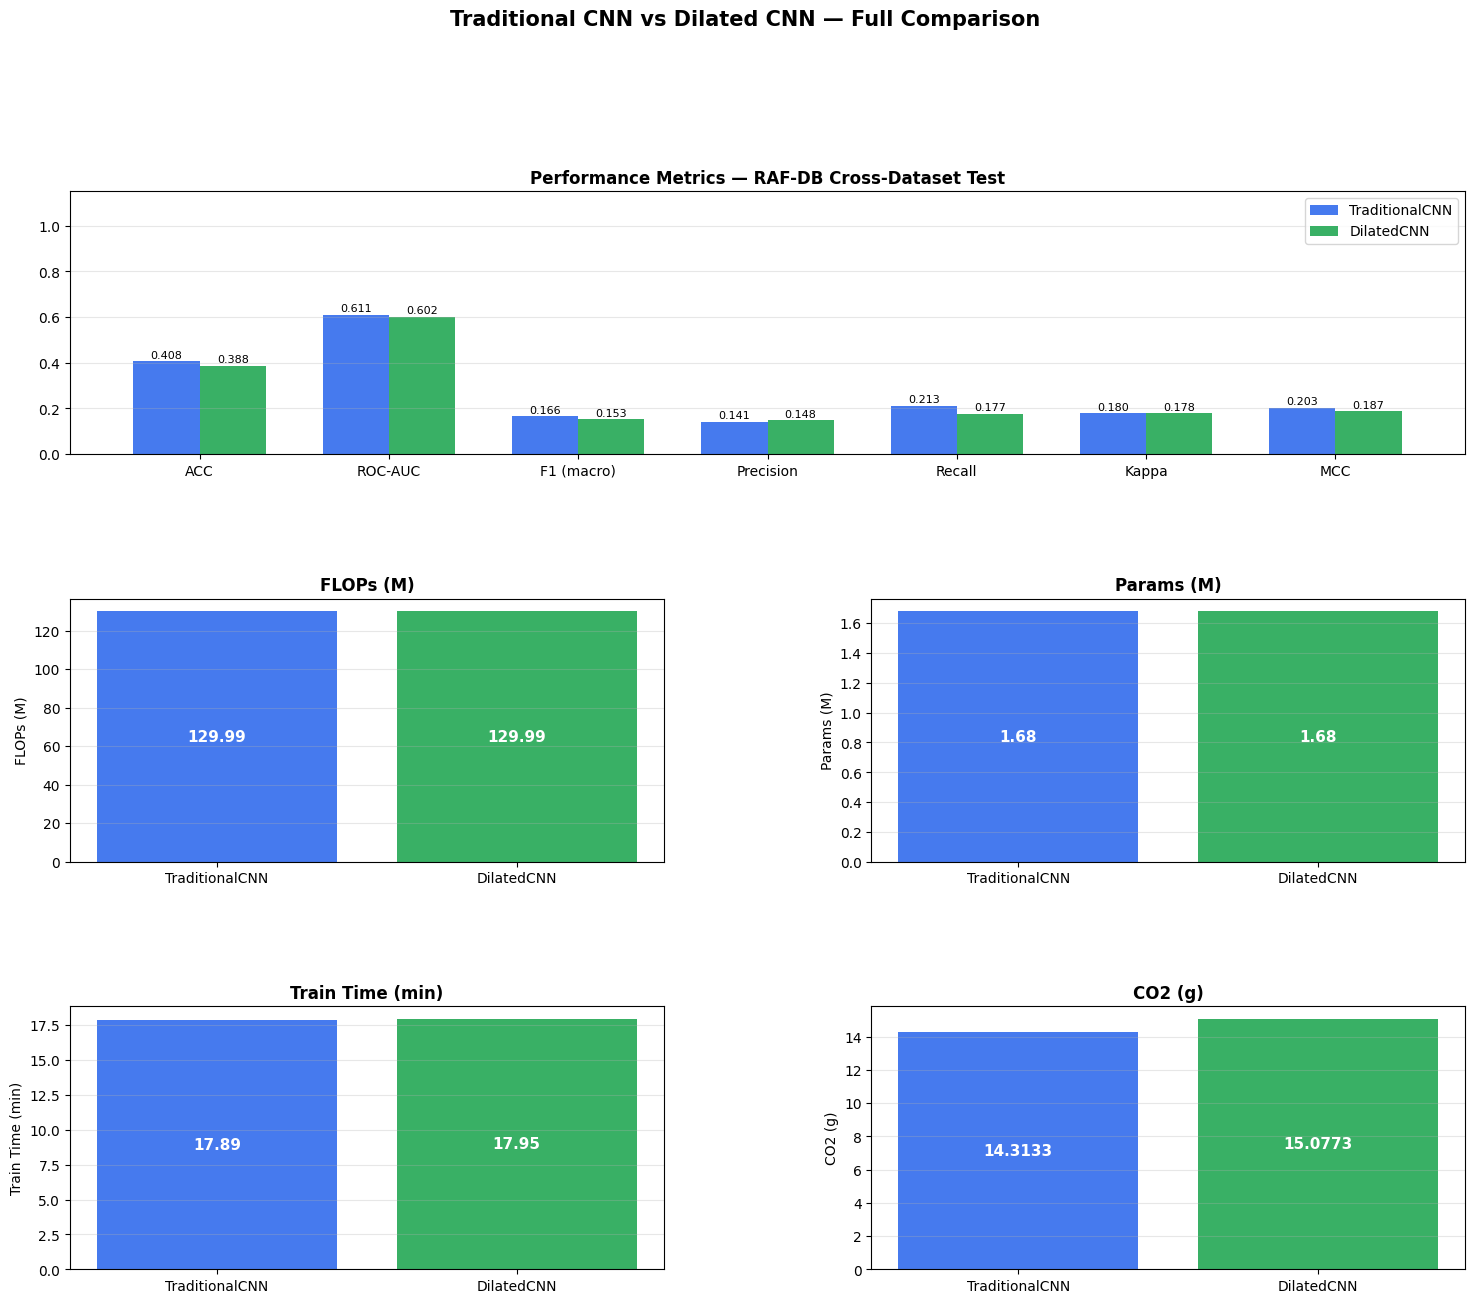


===== FINAL RESULTS TABLE =====
Model             TraditionalCNN  DilatedCNN
ACC                       0.4078      0.3879
ROC-AUC                   0.6110      0.6021
F1 (macro)                0.1659      0.1528
Precision                 0.1415      0.1479
Recall                    0.2130      0.1770
Kappa                     0.1805      0.1784
MCC                       0.2031      0.1873
FLOPs (M)               129.9900    129.9900
Params (M)                1.6800      1.6800
Train Time (min)         17.8900     17.9500
CO2 (g)                  14.3133     15.0773


In [22]:
# Display a styled comparison table and grouped bar chart for all metrics

metric_cols  = ['ACC','ROC-AUC','F1 (macro)','Precision','Recall','Kappa','MCC']
compute_cols = ['FLOPs (M)','Params (M)','Train Time (min)','CO2 (g)']

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)

colors = ['#2563eb', '#16a34a']
models = results_df.index.tolist()
x      = np.arange(len(metric_cols))
width  = 0.35

# --- 1. Performance metrics bar chart ---
ax1 = fig.add_subplot(gs[0, :])
for i, (m, c) in enumerate(zip(models, colors)):
    vals = [results_df.loc[m, col] for col in metric_cols]
    bars = ax1.bar(x + i*width, vals, width, label=m, color=c, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=8)
ax1.set_xticks(x + width/2)
ax1.set_xticklabels(metric_cols)
ax1.set_ylim(0, 1.15)
ax1.set_title('Performance Metrics — RAF-DB Cross-Dataset Test', fontweight='bold')
ax1.legend(); ax1.grid(axis='y', alpha=0.3)

# --- 2. Efficiency metrics (4 individual bars) ---
for idx, col in enumerate(compute_cols):
    row, c_col = divmod(idx, 2)
    ax = fig.add_subplot(gs[row + 1, c_col])
    vals = [results_df.loc[m, col] for m in models]
    bars = ax.bar(models, vals, color=colors, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 0.5,
                f'{v}', ha='center', va='center', color='white', fontweight='bold', fontsize=11)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel(col)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Traditional CNN vs Dilated CNN — Full Comparison', fontsize=15, fontweight='bold', y=1.01)
plt.savefig('/content/comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n===== FINAL RESULTS TABLE =====')
print(results_df.T.to_string())

## 💾 Step 9 — Save Everything

In [26]:
import os, shutil

SAVE_DIR = '/content/FER_Project'
os.makedirs(SAVE_DIR, exist_ok=True)

# Models
shutil.copy('/content/TraditionalCNN_best.h5', f'{SAVE_DIR}/TraditionalCNN_best.h5')
shutil.copy('/content/DilatedCNN_best.h5',     f'{SAVE_DIR}/DilatedCNN_best.h5')

# Results CSV
results_df.to_csv(f'{SAVE_DIR}/results.csv')

# Figures
shutil.copy('/content/learning_curves.png',    f'{SAVE_DIR}/learning_curves.png')
shutil.copy('/content/comparison_results.png', f'{SAVE_DIR}/comparison_results.png')

print('All files saved to /content/FER_Project/')
print(os.listdir(SAVE_DIR))

All files saved to /content/FER_Project/
['DilatedCNN_best.h5', 'comparison_results.png', 'results.csv', 'learning_curves.png', 'TraditionalCNN_best.h5']


In [ ]:
# # Save both trained models (.h5), results CSV, and all figures to Google Drive

# from google.colab import drive
# drive.mount('/content/drive')

# SAVE_DIR = '/content/drive/MyDrive/FER_Project'
# os.makedirs(SAVE_DIR, exist_ok=True)

# # Models — already saved as best checkpoints; copy to Drive
# import shutil
# shutil.copy('/content/TraditionalCNN_best.h5', f'{SAVE_DIR}/TraditionalCNN_best.h5')
# shutil.copy('/content/DilatedCNN_best.h5',     f'{SAVE_DIR}/DilatedCNN_best.h5')

# # Results CSV
# results_df.to_csv(f'{SAVE_DIR}/results.csv')

# # Figures
# shutil.copy('/content/learning_curves.png',    f'{SAVE_DIR}/learning_curves.png')
# shutil.copy('/content/comparison_results.png', f'{SAVE_DIR}/comparison_results.png')

# print('All files saved to Google Drive /FER_Project/')
# print(os.listdir(SAVE_DIR))

Saving Screenshot 2026-05-10 170849.png to Screenshot 2026-05-10 170849.png


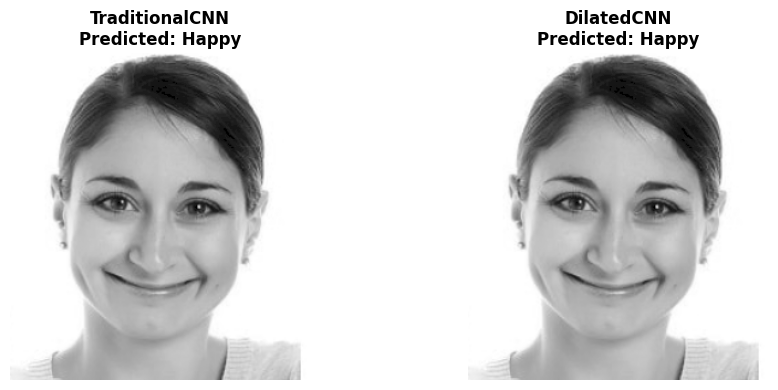

In [29]:
import torch
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from google.colab import files

# --- Load Models ---
trad_model = TraditionalCNN().to(DEVICE)
trad_model.load_state_dict(torch.load('/content/FER_Project/TraditionalCNN_best.h5'))
trad_model.eval()

dila_model = DilatedCNN().to(DEVICE)
dila_model.load_state_dict(torch.load('/content/FER_Project/DilatedCNN_best.h5'))
dila_model.eval()

# --- Predict Function ---
def predict_emotion(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_pil = Image.fromarray(img).convert('L')
    tensor = eval_transforms(img_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        trad_pred = CLASSES[trad_model(tensor).argmax(1).item()]
        dila_pred = CLASSES[dila_model(tensor).argmax(1).item()]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, name, pred in zip(axes, ['TraditionalCNN', 'DilatedCNN'], [trad_pred, dila_pred]):
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{name}\nPredicted: {pred}', fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# --- Upload & Predict ---
uploaded = files.upload()
fname = list(uploaded.keys())[0]
predict_emotion(fname)